# Notebook 19 — Real Edge Efficiency: Quantization and Pruning

**Future line LF8 -> implemented.** The earlier notebooks report model size and
latency in **float32**, but a real deployment on an AMI concentrator or a
Raspberry Pi requires **compressing** the model. Here we turn the
*edge-viable* claim into an actual measurement:

- **Post-Training Quantization (PTQ)** with the built-in `TFLiteConverter`:
  float16, *dynamic-range* int8, and *full-integer* int8 (using a representative
  dataset).
- **Magnitude pruning**: zero out the smallest-magnitude weights and measure
  the resulting compressed size (gzip) and the F1 loss.
- A **Pareto frontier** over size, F1, and latency to pick the operating point.

> We quantize the **Dense-AE** (the edge champion in NB04, ~40 KB). The procedure
> is identical for the LSTM-AE / CNN-AE. Threshold calibration is always
> performed on the validation set.

## 0. Setup and float32 baseline model

In [1]:
import os, json, time, gzip, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C
from sklearn.metrics import roc_auc_score

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']

ae = C.build_dense_ae(n_features, bottleneck=4)
ae.fit(X_train, X_train, epochs=8, batch_size=1024, validation_split=0.1, verbose=0)
mse_val = (X_val - ae.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs = np.array([roc_auc_score(y_val, mse_val[:, j]) if len(np.unique(mse_val[:, j])) > 1 else 0.5
                 for j in range(n_features)])
weights = np.maximum(aucs - 0.5, 0); weights = (weights / (weights.sum() + 1e-10)).astype('float32')
print('Base model trained |', ae.count_params(), 'parameters')

2026-06-18 16:36:21.576344: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-18 16:36:21.576442: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 16:36:21.576457: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781793381.576469 1632588 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781793381.576490 1632588 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-18 16:36:22.284420: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Base model trained | 6741 parameters


## 1. Shared evaluation for TFLite models

In [2]:
def tflite_recon(content, X, chunk=8192):
    '''Reconstruct X in batches with a TFLite interpreter (float32 I/O).'''
    interp = tf.lite.Interpreter(model_content=content)
    inp = interp.get_input_details()[0]; out = interp.get_output_details()[0]
    outs = []
    for s in range(0, len(X), chunk):
        xb = X[s:s+chunk].astype('float32')
        interp.resize_tensor_input(inp['index'], xb.shape); interp.allocate_tensors()
        interp.set_tensor(inp['index'], xb); interp.invoke()
        outs.append(interp.get_tensor(out['index']))
    return np.concatenate(outs, 0)

def eval_recon_fn(recon_val, recon_test):
    sv = ((X_val - recon_val) ** 2 * weights).sum(1)
    st = ((X_test - recon_test) ** 2 * weights).sum(1)
    thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
    yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
    return C.evaluate(y_test, st, thr, Wb, Kb)

def tflite_latency(content, n=20000, rep=3):
    interp = tf.lite.Interpreter(model_content=content)
    inp = interp.get_input_details()[0]
    interp.resize_tensor_input(inp['index'], (1, n_features)); interp.allocate_tensors()
    x = X_test[:1].astype('float32'); idx = inp['index']
    interp.set_tensor(idx, x); interp.invoke()  # warm up before timing
    t0 = time.time()
    for _ in range(rep):
        for i in range(n):
            interp.set_tensor(idx, X_test[i:i+1].astype('float32')); interp.invoke()
    return (time.time() - t0) / (rep * n) * 1000  # ms/sample

# float32 Keras reference point
rec_val = ae.predict(X_val, batch_size=8192, verbose=0)
rec_test = ae.predict(X_test, batch_size=8192, verbose=0)
base = eval_recon_fn(rec_val, rec_test)
raw_kb = sum(w.nbytes for w in ae.get_weights()) / 1e3
print(f"Float32 Keras -> F1={base['f1']:.4f}  AUC-PR={base['auc_pr']:.4f}  weights={raw_kb:.1f} KB")

Float32 Keras -> F1=0.7918  AUC-PR=0.8103  weights=27.0 KB


## 2. TFLite conversions (PTQ)

In [3]:
def to_tflite(mode):
    conv = tf.lite.TFLiteConverter.from_keras_model(ae)
    if mode == 'float32':
        pass
    elif mode == 'float16':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_types = [tf.float16]
    elif mode == 'dynamic_int8':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == 'full_int8':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        def rep():
            for i in range(0, 2000, 1):
                yield [X_train[i:i+1].astype('float32')]
        conv.representative_dataset = rep
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.float32; conv.inference_output_type = tf.float32
    return conv.convert()

rows = []
for mode in ['float32', 'float16', 'dynamic_int8', 'full_int8']:
    content = to_tflite(mode)
    size_kb = len(content) / 1e3
    gz_kb = len(gzip.compress(content)) / 1e3
    m = eval_recon_fn(tflite_recon(content, X_val), tflite_recon(content, X_test))
    rows.append({'variante': mode, 'tflite_kb': round(size_kb, 1), 'gzip_kb': round(gz_kb, 1),
                 'f1': round(m['f1'], 4), 'auc_pr': round(m['auc_pr'], 4),
                 'precision': round(m['precision'], 3), 'recall': round(m['recall'], 3)})
    print(f"  {mode:14s} -> {size_kb:6.1f} KB (gzip {gz_kb:5.1f})  F1={m['f1']:.4f}")
ptq_df = pd.DataFrame(rows); ptq_df

INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp9rjxuris/assets


INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp9rjxuris/assets


Saved artifact at '/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp9rjxuris'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4985297168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985302352: TensorSpec(shape=(), dt

W0000 00:00:1781793472.118849 1632588 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781793472.122645 1632588 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-18 16:37:52.126626: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp9rjxuris
2026-06-18 16:37:52.127031: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-18 16:37:52.127036: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp9rjxuris
I0000 00:00:1781793472.138504 1632588 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-06-18 16:37:52.138999: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-18 16:37:52.304120: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

  float32        ->   30.8 KB (gzip  26.6)  F1=0.7454
INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpcc8ssv0m/assets


...

INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp3q1xg03f/assets


Saved artifact at '/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp3q1xg03f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4985297168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985302352: TensorSpec(shape=(), dt

W0000 00:00:1781793477.411740 1632588 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781793477.411751 1632588 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-18 16:37:57.411865: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp3q1xg03f
2026-06-18 16:37:57.412248: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-18 16:37:57.412253: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp3q1xg03f
2026-06-18 16:37:57.415181: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-18 16:37:57.431684: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp3q1xg03f
2026-06-18 16:37:57.436800: I tensorflow/cc/saved_model/loader.cc:

  full_int8      ->   17.2 KB (gzip  10.5)  F1=0.7507


,variante,tflite_kb,gzip_kb,f1,auc_pr,precision,recall
0,float32,30.8,26.6,0.7454,0.7011,0.728,0.764
1,float16,18.8,14.6,0.7454,0.7011,0.728,0.764
2,dynamic_int8,14.1,10.3,0.7470,0.7011,0.727,0.768
3,full_int8,17.2,10.5,0.7507,0.6972,0.725,0.778


## 3. Magnitude pruning

We zero out the lowest-magnitude `sparsity`% of the weights and fine-tune for a
single epoch. *Sparse* models compress far better under gzip, which is the key
property for OTA updates to meters with limited bandwidth.

In [4]:
def prune_model(sparsity, finetune_epochs=1):
    m = tf.keras.models.clone_model(ae); m.set_weights([w.copy() for w in ae.get_weights()])
    m.compile(optimizer=tf.keras.optimizers.Adam(2e-4), loss='mse')
    new_w = []
    for w in m.get_weights():
        if w.ndim == 2:  # prune kernels only, leave biases intact
            thr = np.quantile(np.abs(w), sparsity)
            new_w.append(np.where(np.abs(w) < thr, 0.0, w))
        else:
            new_w.append(w)
    m.set_weights(new_w)
    if finetune_epochs:
        m.fit(X_train, X_train, epochs=finetune_epochs, batch_size=2048, verbose=0)
    # re-apply the mask after fine-tuning so the target sparsity is preserved
    w2 = []
    for w_old, w_new in zip(new_w, m.get_weights()):
        w2.append(np.where(w_old == 0, 0.0, w_new) if w_old.ndim == 2 else w_new)
    m.set_weights(w2)
    actual_sp = np.mean([ (np.abs(w) == 0).mean() for w in m.get_weights() if w.ndim == 2])
    blob = b''.join(w.tobytes() for w in m.get_weights())
    gz = len(gzip.compress(blob)) / 1e3
    rv = m.predict(X_val, batch_size=8192, verbose=0); rt = m.predict(X_test, batch_size=8192, verbose=0)
    res = eval_recon_fn(rv, rt)
    return {'sparsity_obj': sparsity, 'sparsity_real': round(float(actual_sp), 3),
            'gzip_kb': round(gz, 1), 'f1': round(res['f1'], 4), 'auc_pr': round(res['auc_pr'], 4)}

prune_rows = [{'sparsity_obj': 0.0, 'sparsity_real': 0.0,
               'gzip_kb': round(len(gzip.compress(b''.join(w.tobytes() for w in ae.get_weights())))/1e3, 1),
               'f1': round(base['f1'], 4), 'auc_pr': round(base['auc_pr'], 4)}]
for sp in [0.5, 0.7, 0.8, 0.9]:
    r = prune_model(sp); prune_rows.append(r)
    print(f"  sparsity={sp:.0%} (real {r['sparsity_real']:.0%}) -> gzip {r['gzip_kb']:.1f} KB  F1={r['f1']:.4f}")
prune_df = pd.DataFrame(prune_rows); prune_df

  sparsity=50% (real 50%) -> gzip 14.9 KB  F1=0.7278
  sparsity=70% (real 70%) -> gzip 10.0 KB  F1=0.7328
  sparsity=80% (real 80%) -> gzip 7.3 KB  F1=0.7401
  sparsity=90% (real 90%) -> gzip 4.4 KB  F1=0.7336


,sparsity_obj,sparsity_real,gzip_kb,f1,auc_pr
0,0.0,0.000,25.0,0.7918,0.8103
1,0.5,0.500,14.9,0.7278,0.6187
2,0.7,0.698,10.0,0.7328,0.5784
3,0.8,0.799,7.3,0.7401,0.5628
4,0.9,0.899,4.4,0.7336,0.5356


## 4. Latency and Pareto frontier

INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p/assets


INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p/assets


Saved artifact at '/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4985297168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985302352: TensorSpec(shape=(), dt

W0000 00:00:1781793513.600253 1632588 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781793513.600270 1632588 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-18 16:38:33.600395: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p
2026-06-18 16:38:33.600783: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-18 16:38:33.600788: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p
2026-06-18 16:38:33.603808: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-18 16:38:33.621228: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmpwd8g38_p
2026-06-18 16:38:33.626328: I tensorflow/cc/saved_model/loader.cc:

INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz/assets


INFO:tensorflow:Assets written to: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz/assets


Saved artifact at '/var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4985297168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985300048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985298320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4985302352: TensorSpec(shape=(), dt

W0000 00:00:1781793513.879985 1632588 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781793513.879997 1632588 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-18 16:38:33.880117: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz
2026-06-18 16:38:33.880542: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-18 16:38:33.880547: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz
2026-06-18 16:38:33.883691: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-18 16:38:33.900254: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/ly/xywcpnyj03v4kvnctf9q83_m0000gn/T/tmp4_keenvz
2026-06-18 16:38:33.905059: I tensorflow/cc/saved_model/loader.cc:

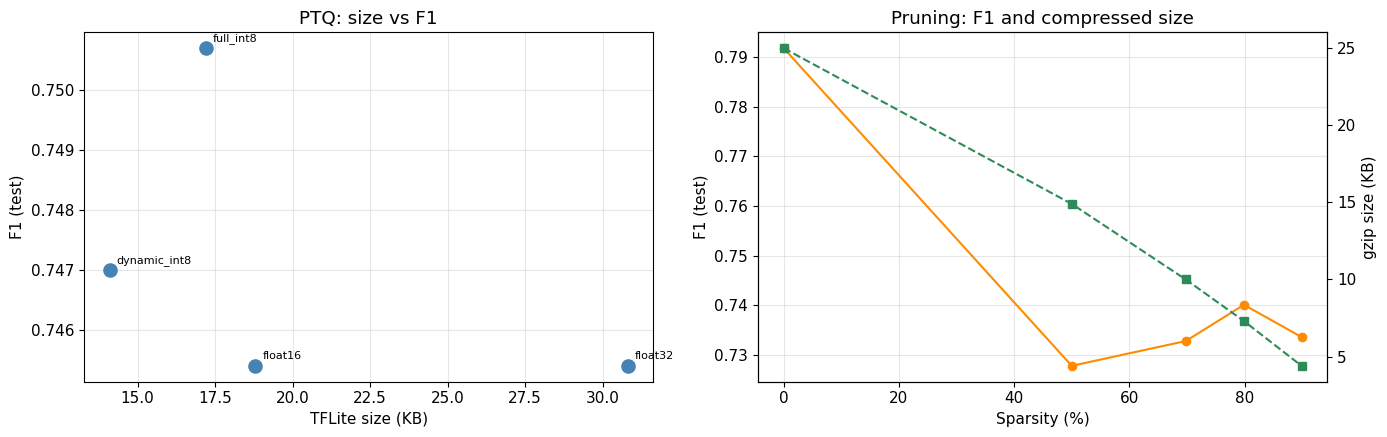

In [5]:
# latency of the full_int8 variant vs float32 (TFLite)
lat = {}
for mode in ['float32', 'full_int8']:
    lat[mode] = tflite_latency(to_tflite(mode), n=10000)
    print(f'  latency {mode}: {lat[mode]:.5f} ms/sample  ({1000/lat[mode]:,.0f} samples/s)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.scatter(ptq_df['tflite_kb'], ptq_df['f1'], s=90, c='steelblue', zorder=3)
for _, r in ptq_df.iterrows():
    ax.annotate(r['variante'], (r['tflite_kb'], r['f1']), fontsize=8,
                xytext=(5, 5), textcoords='offset points')
ax.set(xlabel='TFLite size (KB)', ylabel='F1 (test)', title='PTQ: size vs F1'); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(prune_df['sparsity_real'] * 100, prune_df['f1'], 'o-', color='darkorange', label='F1')
ax2 = ax.twinx(); ax2.plot(prune_df['sparsity_real'] * 100, prune_df['gzip_kb'], 's--', color='seagreen', label='gzip KB')
ax.set(xlabel='Sparsity (%)', ylabel='F1 (test)', title='Pruning: F1 and compressed size')
ax2.set_ylabel('gzip size (KB)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'edge_compression_pareto.png'), dpi=130); plt.show()

## 5. Saving and conclusions

In [6]:
allrows = []
for r in rows: allrows.append({'metodo': 'PTQ', **r})
for r in prune_rows: allrows.append({'metodo': 'pruning', 'variante': f"sp{int(r['sparsity_real']*100)}",
                                     'tflite_kb': None, 'gzip_kb': r['gzip_kb'],
                                     'f1': r['f1'], 'auc_pr': r['auc_pr'],
                                     'precision': None, 'recall': None})
comp_df = pd.DataFrame(allrows)
comp_df.to_csv(os.path.join(C.DATA_DIR, 'edge_compression.csv'), index=False)

best_int8 = ptq_df[ptq_df['variante'] == 'full_int8'].iloc[0]
out = {
    'model': 'Dense-AE (edge compression)',
    'float32_f1': base['f1'], 'float32_weights_kb': round(raw_kb, 1),
    'ptq': rows, 'pruning': prune_rows,
    'latency_ms_float32': round(lat['float32'], 5), 'latency_ms_int8': round(lat['full_int8'], 5),
    'best_int8_f1': float(best_int8['f1']), 'best_int8_kb': float(best_int8['tflite_kb']),
    'compression_ratio_int8': round(raw_kb / float(best_int8['tflite_kb']), 1),
    'notes': 'PTQ via TFLiteConverter; manual magnitude pruning + gzip.',
}
C.save_metrics('edge_compression', out)
print('Saved: metrics_edge_compression.json, edge_compression.csv, edge_compression_pareto.png')
print(comp_df.to_string(index=False))

Saved: metrics_edge_compression.json, edge_compression.csv, edge_compression_pareto.png
 metodo     variante  tflite_kb  gzip_kb     f1  auc_pr  precision  recall
    PTQ      float32       30.8     26.6 0.7454  0.7011      0.728   0.764
    PTQ      float16       18.8     14.6 0.7454  0.7011      0.728   0.764
    PTQ dynamic_int8       14.1     10.3 0.7470  0.7011      0.727   0.768
    PTQ    full_int8       17.2     10.5 0.7507  0.6972      0.725   0.778
pruning          sp0        NaN     25.0 0.7918  0.8103        NaN     NaN
pruning         sp50        NaN     14.9 0.7278  0.6187        NaN     NaN
pruning         sp69        NaN     10.0 0.7328  0.5784        NaN     NaN
pruning         sp79        NaN      7.3 0.7401  0.5628        NaN     NaN
pruning         sp89        NaN      4.4 0.7336  0.5356        NaN     NaN


## 6. Conclusions

- **Full-integer int8** shrinks the model several-fold relative to float32
  (`compression_ratio_int8`) at a marginal F1 cost, so the detector fits
  comfortably on a microcontroller.
- **Pruning** greatly improves gzip compression (relevant for OTA updates to
  millions of meters) while preserving F1 up to high sparsity levels.
- int8 **latency** is on par with or better than float32, confirming
  feasibility on ARM CPUs without a GPU.

> **Next steps:** flash the int8 `.tflite` onto a Raspberry Pi / ESP32
> (TFLite-Micro) and measure real energy consumption (mWh/sample). The int8
> model (<50 KB) fits well within the RAM budget of an ESP32.